# Exercise 1: Radioactive decay chain

$^{213}\text{Bi} → \begin{cases} ^{209}\text{Tl} \xrightarrow{2.09\%} \,\, ^{209}\text{Pb} → \,\, ^{209}\text{Bi} \\ ^{209}\text{Pb} \xrightarrow{97.09\%}  \,\, ^{209}\text{Bi} \end{cases}$


Probability of decay, $P(t) = 1 - 2^{-t/\tau}$

$\tau_{\,\, ^{213}Bi} =  46 min = 2760s\\
 \tau_{\,\, ^{209}Tl} = 2.2 min = 132s\\
 \tau_{\,\, ^{209}Pb} = 3.3 min = 198s\\
 \tau_{\,\,^{209}Bi} = \text{half of the life of universe (Stable)}
$



a)

In [ ]:
tau_Pb = 198
tau_Tl = 132
tau_Bi = 2760
N_Bi213 =10000
N_Pb209 = 0
N_Tl209 = 0
N_Bi209 = 0
dt = 1

p_Pb209 = 1-2**(-dt/tau_Pb)
p_Tl209 = 1-2**(-dt/tau_Tl)
p_Bi213 = 1-2**(-dt/tau_Bi)

In [ ]:
import numpy as np

decays = 0
for i in range(N_Pb209):
  r = np.random.rand()
  if r < p_Pb209:
    decays += 1

N_Pb209 = N_Pb209 - decays
N_Bi209 = N_Bi209 + decays

b)

In [ ]:
decays = 0
for i in range(N_Tl209):
  r = np.random.rand()
  if r < p_Tl209:
    decays += 1

N_Tl209 = N_Tl209 - decays
N_Pb209 = N_Pb209 + decays

c)

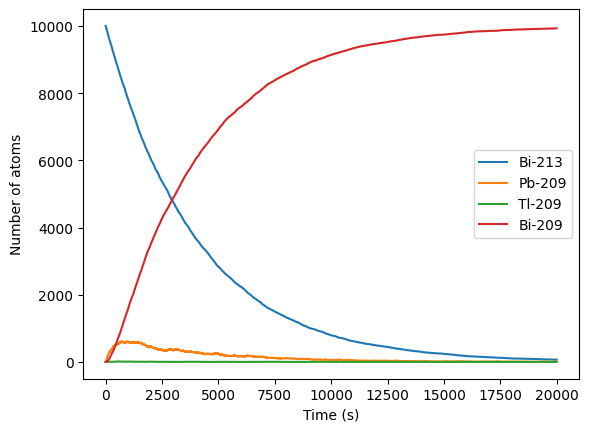

In [ ]:
t_max = 20000

Bi213_list = []
Pb209_list = []
Tl209_list = []
Bi209_list = []

for t in range(t_max):

  # ---- Pb to Bi ----
  decays = np.sum(np.random.rand(N_Pb209) < p_Pb209)
  N_Pb209 -= decays
  N_Bi209 += decays

  # ---- Tl to Pb ----
  decays = np.sum(np.random.rand(N_Tl209) < p_Tl209)
  N_Tl209 -= decays
  N_Pb209 += decays

  # ---- Bi213 to Pb or Tl ----
  decays = np.sum(np.random.rand(N_Bi213) < p_Bi213)

  # branching
  to_Pb = np.sum(np.random.rand(decays) < 0.9791)
  to_Tl = decays - to_Pb

  N_Bi213 -= decays
  N_Pb209 += to_Pb
  N_Tl209 += to_Tl

  Bi213_list.append(N_Bi213)
  Pb209_list.append(N_Pb209)
  Tl209_list.append(N_Tl209)
  Bi209_list.append(N_Bi209)

import matplotlib.pyplot as plt
plt.plot(Bi213_list, label="Bi-213")
plt.plot(Pb209_list, label="Pb-209")
plt.plot(Tl209_list, label="Tl-209")
plt.plot(Bi209_list, label="Bi-209")

plt.xlabel("Time (s)")
plt.ylabel("Number of atoms")
plt.legend()
plt.show()

# Exercise 2: Brownian Motion



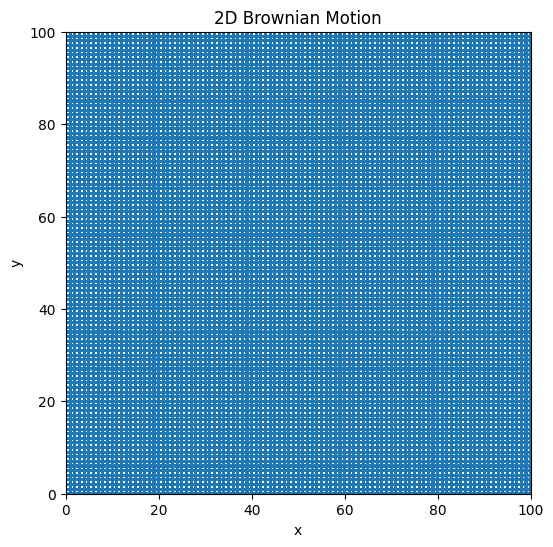

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 101
N_steps = 1000000

# Start at center
x, y = L // 2, L // 2

x_traj = [x]
y_traj = [y]

# Random walk
for _ in range(N_steps):
  direction = np.random.randint(0, 4)

  if direction == 0:      # up
    if y < L - 1:
      y += 1
  elif direction == 1:    # down
    if y > 0:
      y -= 1
  elif direction == 2:    # right
    if x < L - 1:
      x += 1
  elif direction == 3:    # left
    if x > 0:
      x -= 1
  x_traj.append(x)
  y_traj.append(y)

plt.figure(figsize=(6,6))
plt.plot(x_traj, y_traj)
plt.title("2D Brownian Motion")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(0, L-1)
plt.ylim(0, L-1)
plt.show()

# Exercise 3



a) $$I = \int_{0}^{2} sin^2\left[ \frac{1}{x(2-x)} \right]dx$$

Using hit and miss Monte Carlo
  - Domain $x \in (0,2)$
  - Range $y \in [0,1] $
  - Generate two random numbers in x and y
  - With x calculate f(x)
  - f(x) lies within rectangle $x \in (0,2) \,\,, y \in [0,1] $
  - $$\frac{Area(f(x))}{Area(rectangle)} = \frac{N_{inside}}{N} \implies \boxed{I = A(rectangle) \frac{N_{inside}}{N}}$$

In [ ]:
import numpy as np

N = 10000
count = 0

for _ in range(N):
  x = 2 * np.random.rand()

  # avoid singularity exactly at 0 or 2
  if x == 0 or x == 2:
    continue

  y = np.random.rand()

  f = np.sin(1 / (x * (2 - x)))**2

  if y < f:
      count += 1

I = 2 * count / N

# Error estimate (binomial)
p = count / N
error = 2 * np.sqrt(p * (1 - p) / N)

print("Integral =", I)
print("Error =", error)

Integral = 1.4594
Error = 0.00888229497371034


b)

$$I = \int_{a}^{b} f(x)dx$$
$$⟨f(x)⟩ = \frac{1}{b-a} \int_{a}^{b} f(x)dx \implies I = (b-a) ⟨f(x)⟩$$
$$\boxed{I ≈ \frac{b-a}{N} Σ_{i=1}^{N} f(x_i)}$$

In [ ]:
N = 10000
values = []

for i in range(N):
  x = 2 * np.random.rand()

  if x == 0 or x == 2:
    continue

  f = np.sin(1 / (x * (2 - x)))**2
  values.append(f)

values = np.array(values)

I = 2 * np.mean(values)

# Error estimate
error = 2 * np.std(values) / np.sqrt(N)

print("Integral =", I)
print("Error =", error)

Integral = 1.4595255492080752
Error = 0.005261179002392241


# Exercise 4: Volume of hypersphere

2D example:
$$I = \int\int_{-1}^{1}f(x,y) dxdy, \qquad \text{where f(x,y) = 1}$$

$$f(x,y) =\begin{cases} 1, \quad \text{if} \,\, x^2+y^2 = 1 \\ 0 \quad \text{otherwise} \end{cases}$$

$$ I ≈ \frac{4}{N} \Sigma_{i =1}^{N} f(x_i,y_i)$$

Similarly for 10D:
  - Generate random numbers in 10 independent axis within range (-1,1).
  - Check if random numbers lie within 10D sphere if yes count as $N_{samples}$.
  - $$\boxed{Volume = 2^{10}\frac{N_{samples}}{N}}$$

In [ ]:
import numpy as np

# Parameters
N = 1000000
d = 10

count = 0

for i in range(N):
  x = np.random.uniform(-1, 1, d)
  r2 = np.sum(x**2)

  if r2 <= 1:
    count += 1

# Volume estimate
V = (2**d) * count / N

# Error estimate
p = count / N
error = (2**d) * np.sqrt(p * (1 - p) / N)

print("Estimated Volume =", V)
print("Error =", error)

Estimated Volume = 2.479104
Error = 0.05032351874975739


# Exercise 5

$$ I = \int_{0}^{1}\frac{x^{-1/2}}{e^x +1}dx$$

$$w(x) = x^{-1/2}$$

a)  $$p(x) = \frac{1}{2\sqrt{x}}$$

For $w(x) = x^{-1/2}$

Normalized weight$$ \implies p(x) = \frac{w(x)}{\int_{0}^{1} w(x)dx} = \frac{1}{2\sqrt{x}}$$

Transformation(CDF):

$$P(x) = \int_x p(x')dx' = \sqrt{x} = y \implies x = y^2$$
For uniform samples $x \in (0,1]$ we have non uniform samples in $y^2$.



b)

$$I = \int_{a}^{b} f(x)dx$$

$$⟨g⟩_w = \frac{\int_{a}^{b} w(x)g(x)dx}{\int_{a}^{b} w(x)dx}$$

Putting $g = \frac{f}{w}$
$$\left\langle \frac{f}{w}\right\rangle = \frac{\int_{a}^{b} f(x)dx}{\int_{a}^{b}w(x)dx} \implies I = \int_{a}^{b}f(x)dx = \left\langle \frac{f(x)}{w(x)}\right\rangle \int_{a}^{b} w(x)dx$$

$$\implies \boxed{I = \frac{1}{N} \Sigma_{i=1}^{N}\left( \frac{f(x_i)}{w(x_i)} \right)\int_{a}^{b} w(x) dx}$$

Putting all together $w(x) = x^{-1/2}$ and $f(x) = \frac{x^{-1/2}}{e^x +1}$ $\implies \frac{f}{w} = \frac{1}{e^x +1}$ and $\int_{0}^{1} x^{-1/2}dx = 2.$




In [ ]:
import numpy as np

N = 1000000

# generate URNs
y = np.random.rand(N)

# transform
x = y**2

# importance sampling
values = 2 / (np.exp(x) + 1)

I = np.mean(values)

# error estimate
error = np.std(values) / np.sqrt(N)

print("Integral =", I)
print("Error =", error)

Integral = 0.838960013827712
Error = 0.00014080162918168423


# Exercise 6:  Ising Model



a)

$$E = -J \sum_{⟨ij⟩} s_is_j$$ for given i j's are adjacent spins $i\pm1$ and $j\pm1$ with value $s =\pm1 $

Each spin has 4 neighbours, however if we count each pairs for every spin we count 2 times of all pair after incorporating periodic boundary condition instead we can choose either of right or left and either of up or down.





In [ ]:
import numpy as np

def compute_energy(spins, J=1):
  L = spins.shape[0]
  E = 0

  for i in range(L):
    for j in range(L):
      s = spins[i, j]

      # periodic boundary conditions
      right = spins[i, (j+1)%L]
      down = spins[(i+1)%L, j]

      E += -J * s * (right + down)

  return E

b)

T = 1

$k_b = 1$

$$E = -J\sum_{⟨i⟩} s_{ij}(s[i+1,j]+s[i-1,j]+s[i,j+1]+s[i,j-1])$$

After flipping $s_{ij}$
$$E' = -J\sum_{⟨i⟩} s'_{ij}(s[i+1,j]+s[i-1,j]+s[i,j+1]+s[i,j-1])$$

$$dE = E'-E = 2Js(s[i+1,j]+s[i-1,j]+s[i,j+1]+s[i,j-1])$$

Metropolis Algorithm:
  - If $ΔE < 0 \implies P >1$, accept change with P = 1
  - If $ΔE > 0 \implies P < 1$, accept change with P.





In [ ]:
def metropolis_step(spins, T=1, J=1):
  L = spins.shape[0]

  i = np.random.randint(L)
  j = np.random.randint(L)

  s = spins[i, j]

  # neighbors (periodic)
  neighbors = (
    spins[(i+1)%L, j] +
    spins[(i-1)%L, j] +
    spins[i, (j+1)%L] +
    spins[i, (j-1)%L])

  dE = 2 * J * s * neighbors

  if dE <= 0 or np.random.rand() < np.exp(-dE/T):
    spins[i, j] *= -1

c)

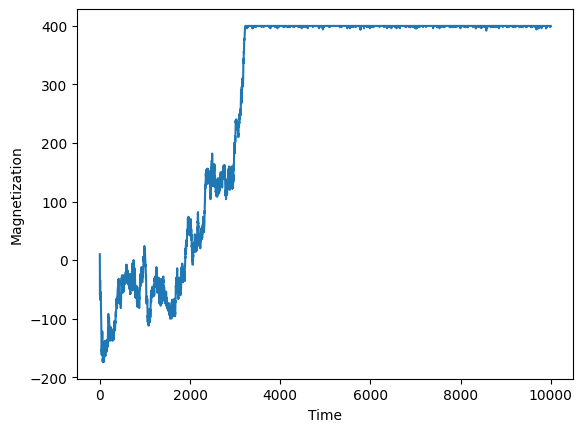

In [ ]:
import matplotlib.pyplot as plt

L = 20
spins = np.random.choice([-1, 1], size=(L, L))

steps = 1000000
M_values = []

for step in range(steps):
  metropolis_step(spins, T=1)

  if step % 100 == 0:
    M_values.append(np.sum(spins))

plt.plot(M_values)
plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.show()

d)

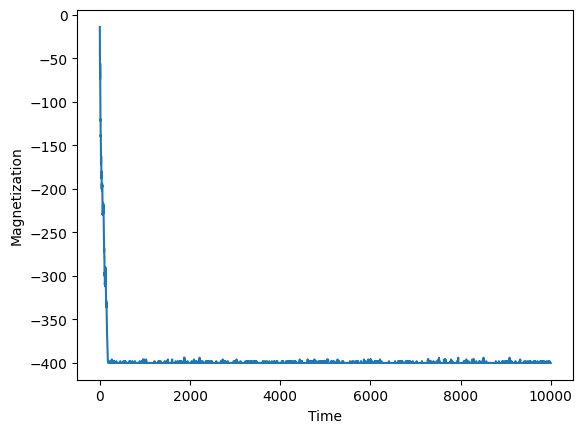

In [ ]:
import matplotlib.pyplot as plt

L = 20
spins = np.random.choice([-1, 1], size=(L, L))

steps = 1000000
M_values = []

for step in range(steps):
  metropolis_step(spins, T=1)

  if step % 100 == 0:
    M_values.append(np.sum(spins))

plt.plot(M_values)
plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.show()

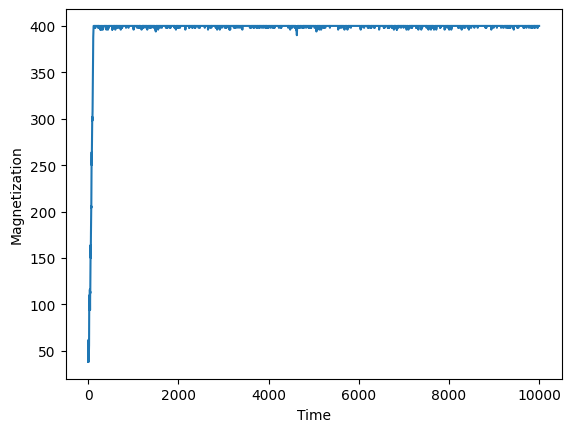

In [ ]:
import matplotlib.pyplot as plt

L = 20
spins = np.random.choice([-1, 1], size=(L, L))

steps = 1000000
M_values = []

for step in range(steps):
  metropolis_step(spins, T=1)

  if step % 100 == 0:
    M_values.append(np.sum(spins))

plt.plot(M_values)
plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.show()

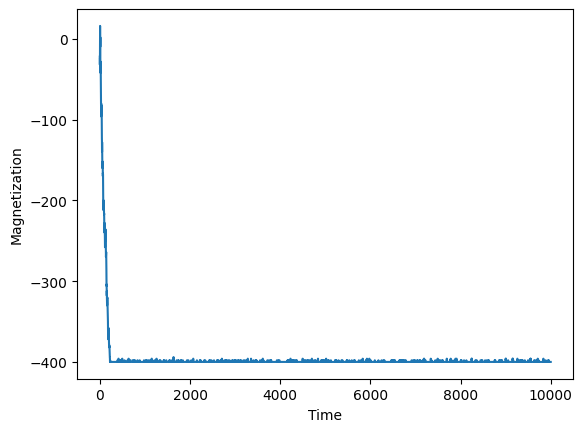

In [ ]:
import matplotlib.pyplot as plt

L = 20
spins = np.random.choice([-1, 1], size=(L, L))

steps = 1000000
M_values = []

for step in range(steps):
  metropolis_step(spins, T=1)

  if step % 100 == 0:
    M_values.append(np.sum(spins))

plt.plot(M_values)
plt.xlabel("Time")
plt.ylabel("Magnetization")
plt.show()

  - Starts initially at 0
  - Then quickly goes saturates to either positive or negative values
  
  System has two equivalent ground states:

    - All spin up
    - All spin down

e)

In [ ]:
def plot_spins(spins, title=""):
  plt.imshow(spins, cmap='coolwarm')
  plt.colorbar()
  plt.title(title)
  plt.show()

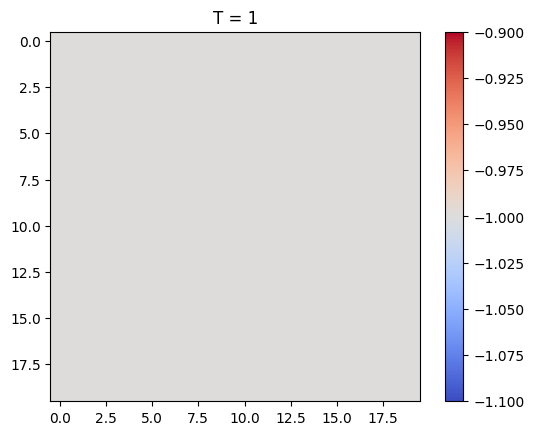

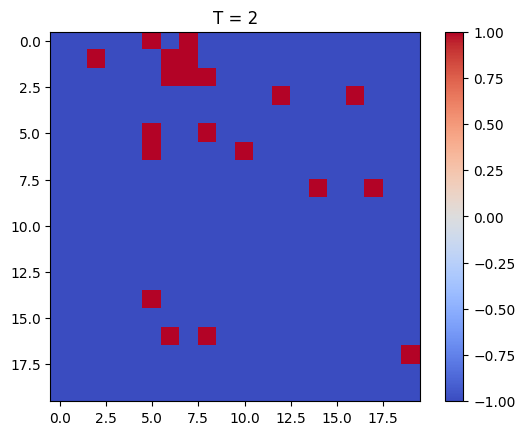

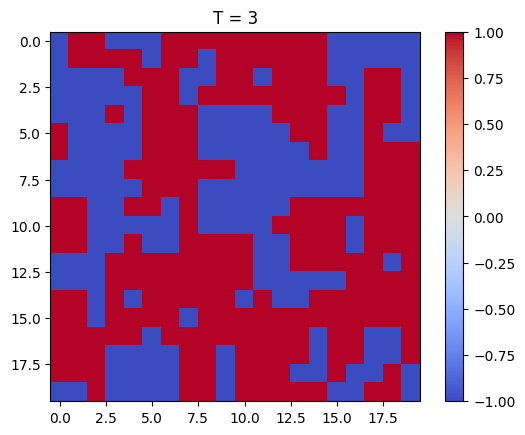

In [ ]:
for T in [1, 2, 3]:
  spins = np.random.choice([-1, 1], size=(20, 20))

  for _ in range(100000):
    metropolis_step(spins, T=T)

  plot_spins(spins, title=f"T = {T}")

  - T = 1, Ordered spread
  - T = 2, Cluster of shapes
  - T = 3, More random spread

  There are two competitive factors magnetization energy and thermal energy,

    - Low temperature shows magnetization energy dominates and we see ordered behaviour
    - With incresing temperature thermal fluctuation become comparable and eventually phase transition emerges.
    - With more thermal energy, disordered state is attained with nearly zero magnetization.

# Exercise 7: Global minimum of a function

$$f(x) = x^2 - cos(4\pi x)$$

a)

  - Starting point x = 2.
  - Move x to $x+\delta$ where $\delta$ is random number drawn from Gaussian distribution with mean 0 and standard deviation 1.
  - Use exponential cooling
  $$ T → \alpha T \implies T_{n+1} = \alpha^{n}T_0$$



Final x: -0.002429568100529212


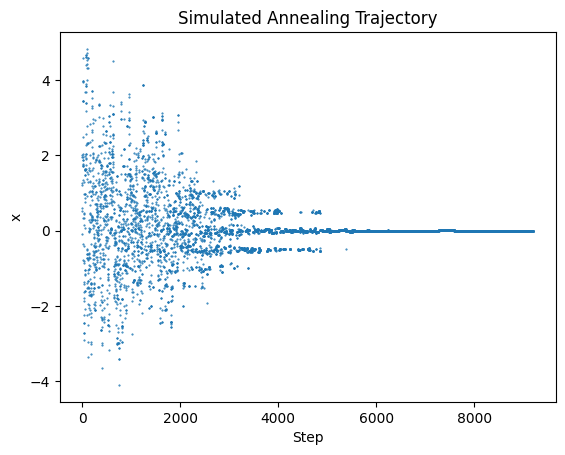

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2 - np.cos(4*np.pi*x)

x = 2.0
T = 10.0           # initial temperature
T_min = 1e-3
alpha = 0.999      # cooling rate
steps = 50000

x_vals = []

for i in range(steps):
  # move
  delta = np.random.normal(0, 1)
  x_new = x + delta

  # Energy difference
  dE = f(x_new) - f(x)

  # Metropolis Algo
  if dE < 0 or np.random.rand() < np.exp(-dE / T):
    x = x_new

  x_vals.append(x)

  # Cooling
  T *= alpha
  if T < T_min:
    break

print("Final x:", x)

plt.plot(x_vals, '.', markersize=1)
plt.xlabel("Step")
plt.ylabel("x")
plt.title("Simulated Annealing Trajectory")
plt.show()

b)

Final x: 15.95917639219733


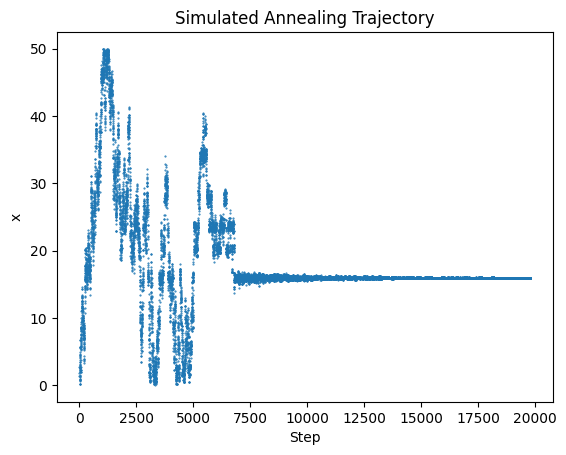

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.cos(x) + np.cos(np.sqrt(2)*x) + np.cos(np.sqrt(3)*x)

x = 2
T = 20
T_min = 1e-3
alpha = 0.9995
steps = 80000

x_vals = []

for i in range(steps):
  # move
  delta = np.random.normal(0, 1)
  x_new = x + delta

  if x_new < 0 or x_new > 50:
    x_vals.append(x)
    T *= alpha
    continue

  # Energy difference
  dE = f(x_new) - f(x)

  # Metropolis Algo
  if dE < 0 or np.random.rand() < np.exp(-dE / T):
      x = x_new

  x_vals.append(x)

  # Cooling
  T *= alpha
  if T < T_min:
    break

print("Final x:", x)

plt.plot(x_vals, '.', markersize=1)
plt.xlabel("Step")
plt.ylabel("x")
plt.title("Simulated Annealing Trajectory")
plt.show()

(b) from multiple execution of above code it can be seen that x settles near 2, 16 and 42.

# Exercise 8:

$$p(\theta, \phi)d\theta d\phi = \frac{sin\theta d\theta}{2} \frac{d\phi}{2\pi} = p(\theta)d\theta p(\phi)d\phi$$

a)

$$p(\theta) = \frac{sin\theta}{2}\\ p(\phi) = \frac{1}{2\pi}$$

$$\theta \in [0,\pi]\\ \phi \in [0,2\pi]$$

$$\int_{0}^{\pi} p(\theta)d\theta = \left[ \frac{-cos\theta}{2}\right]_{0}^{\pi} = 1$$

$$\int_{0}^{2\pi} p(\phi)d\phi = \left[\frac{\phi}{2\pi}\right]_{0}^{2\pi} = 1$$

b)

CDF:

$$ \int_{\phi} p(\phi)d\phi = \frac{\phi}{2\pi} =r_1 \implies \phi = 2\pi r_1$$

$$\int_{\theta} p(\theta)d\theta = \left[ \frac{-cos\theta}{2} \right]_{0}^{\theta} = \frac{1}{2}(1-cos\theta) = r_2 \implies \theta = cos^{-1}(1-2r_2)$$

$r_1$ and $r_2$ are two of the URN which gives $\theta$ and $\phi$ non uniformly distributed random numbers.


c)

In [ ]:
import numpy as np

# Generate one random point
r1 = np.random.rand()
r2 = np.random.rand()

phi = 2 * np.pi * r1
theta = np.arccos(1 - 2 * r2)

# Convert to Cartesian coordinates (optional)
x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)

print("theta =", theta)
print("phi =", phi)
print("Point =", (x, y, z))

theta = 1.5912419507156739
phi = 3.1403549561162794
Point = (np.float64(-0.9997902297247966), np.float64(0.0012374384732495999), np.float64(-0.020444199491876824))


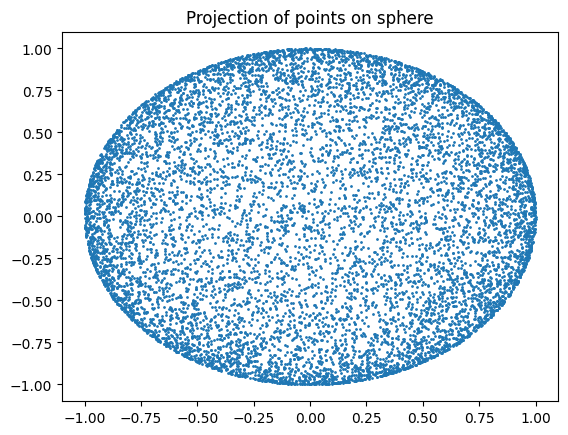

In [ ]:
import matplotlib.pyplot as plt

N = 10000
xs, ys, zs = [], [], []

for _ in range(N):
    r1, r2 = np.random.rand(), np.random.rand()
    phi = 2*np.pi*r1
    theta = np.arccos(1 - 2*r2)

    x = np.sin(theta)*np.cos(phi)
    y = np.sin(theta)*np.sin(phi)
    z = np.cos(theta)

    xs.append(x)
    ys.append(y)
    zs.append(z)

plt.scatter(xs, ys, s=1)
plt.title("Projection of points on sphere")
plt.show()